# CD Polynomial in VAE Latent Space

Experiment: encode 2D obstacle-avoidance trajectories with a Conv VAE,
fit a CD polynomial (Hermite basis) as a safety set in latent space,
and check how well trajectory length can be approximated by a polynomial in z.

In [356]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from data.obstacle_trajectories import generate_trajectories, trajectory_length
from models.conv_vae import ConvVAE, train_vae
from algs.poly_basis import BasisSpec, HermiteBasis

## 1. Generate data

In [357]:
data = generate_trajectories(n_success=2000, n_fail=2000, T=100, seed=42)
trajs = data["trajectories"]  # (4000, 100, 2)
lengths = data["lengths"]
success = data["success"]

print(f"Trajectories: {trajs.shape}")
print(f"Success: {success.sum()}, Fail: {(~success).sum()}")
print(f"Length range: [{lengths.min():.3f}, {lengths.max():.3f}]")

Trajectories: (4000, 100, 2)
Success: 2000, Fail: 2000
Length range: [1.000, 2.472]


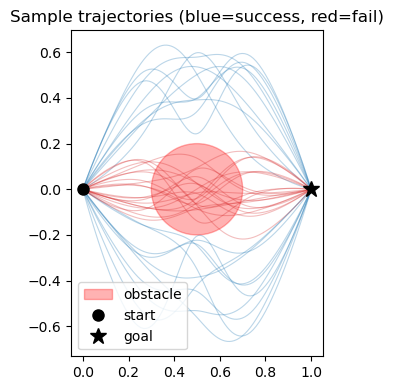

In [358]:
fig, ax = plt.subplots(figsize=(8, 4))
obs = plt.Circle((0.5, 0.0), 0.2, color="red", alpha=0.3, label="obstacle")
ax.add_patch(obs)

n_plot = 20
success_idx = np.where(success)[0][:n_plot]
fail_idx = np.where(~success)[0][:n_plot]

for i in success_idx:
    ax.plot(trajs[i, :, 0], trajs[i, :, 1], "C0", alpha=0.3, lw=0.8)
for i in fail_idx:
    ax.plot(trajs[i, :, 0], trajs[i, :, 1], "C3", alpha=0.3, lw=0.8)

ax.plot(0, 0, "ko", ms=8, label="start")
ax.plot(1, 0, "k*", ms=12, label="goal")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Sample trajectories (blue=success, red=fail)")
plt.tight_layout()

## 2. Train VAE

In [392]:
device = "cuda" if torch.cuda.is_available() else "cpu"
LATENT_DIM = 2
DEGREE = 3  # basis degree for moment regularizer

X_tensor = torch.tensor(trajs)
ds = TensorDataset(X_tensor)
dl = DataLoader(ds, batch_size=256, shuffle=True)

model = ConvVAE(
    in_len=100,
    in_chan=2,
    hidden_dim=100,
    latent_dim=LATENT_DIM,
    start=torch.tensor([0.0, 0.0]),
    goal=torch.tensor([1.0, 0.0]),
)

# Basis for moment regularizer (same one we'll use for CD / cost regression)
train_basis = HermiteBasis(BasisSpec(n_vars=LATENT_DIM, degree=DEGREE))
print(f"Training basis: {train_basis}")

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = train_vae(model, dl, opt, epochs=100, device=device,
                    basis=train_basis, alpha=0.1, endpoint_weight=1.0)

Training basis: HermiteBasis(n_vars=2, degree=3, n_terms=10)
Epoch   0: loss=8.3710  recon=0.1501  logdet-tr=-81.03
Epoch   1: loss=3.2352  recon=0.0552  logdet-tr=-31.52
Epoch   2: loss=1.5006  recon=0.0220  logdet-tr=-14.73
Epoch   3: loss=1.3662  recon=0.0112  logdet-tr=-13.54
Epoch   4: loss=1.2758  recon=0.0070  logdet-tr=-12.68
Epoch   5: loss=1.2619  recon=0.0055  logdet-tr=-12.56
Epoch   6: loss=1.2924  recon=0.0046  logdet-tr=-12.88
Epoch   7: loss=1.2875  recon=0.0038  logdet-tr=-12.83
Epoch   8: loss=1.2969  recon=0.0036  logdet-tr=-12.93
Epoch   9: loss=1.2502  recon=0.0035  logdet-tr=-12.47
Epoch  10: loss=1.2344  recon=0.0030  logdet-tr=-12.31
Epoch  11: loss=1.2209  recon=0.0028  logdet-tr=-12.18
Epoch  12: loss=1.2168  recon=0.0027  logdet-tr=-12.14
Epoch  13: loss=1.2203  recon=0.0026  logdet-tr=-12.18
Epoch  14: loss=1.2165  recon=0.0025  logdet-tr=-12.14
Epoch  15: loss=1.2220  recon=0.0025  logdet-tr=-12.19
Epoch  16: loss=1.2390  recon=0.0024  logdet-tr=-12.36
Epoc

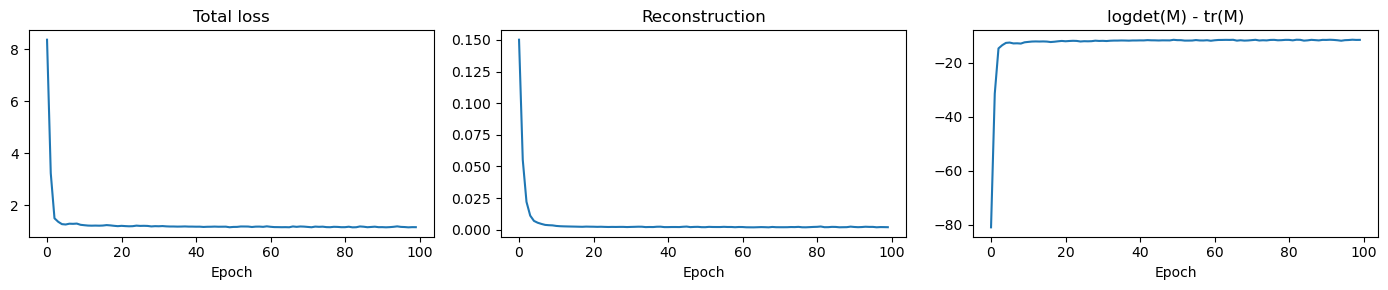

In [393]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(history["loss"]); axes[0].set_title("Total loss")
axes[1].plot(history["recon"]); axes[1].set_title("Reconstruction")
axes[2].plot(history["moment"]); axes[2].set_title("logdet(M) - tr(M)")
for ax in axes: ax.set_xlabel("Epoch")
plt.tight_layout()

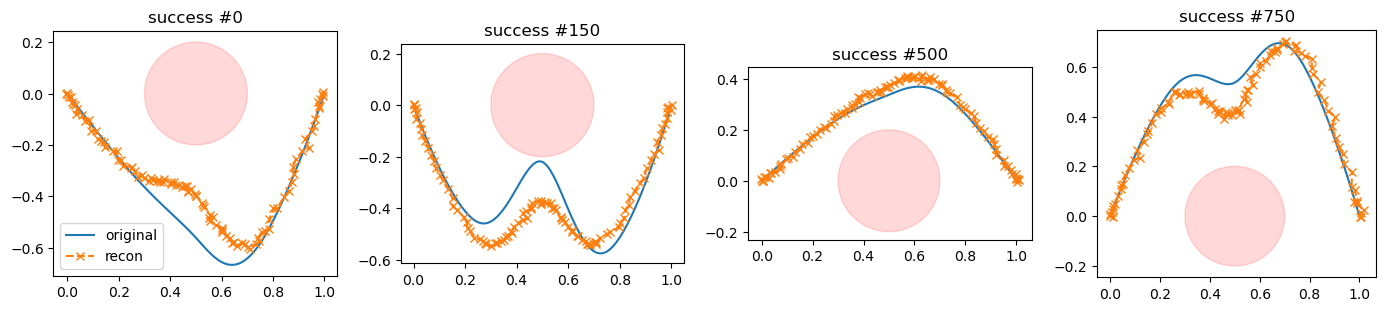

In [394]:
# Plot a few reconstructions
model.eval()
idx = [0, 150, 500, 750]
fig, axes = plt.subplots(1, len(idx), figsize=(14, 3))
for ax, i in zip(axes, idx):
    xi = X_tensor[i:i+1].to(device)
    xhat = model.reconstruct(xi).cpu().numpy()[0]
    orig = trajs[i]
    ax.plot(orig[:, 0], orig[:, 1], "C0", label="original")
    ax.plot(xhat[:, 0], xhat[:, 1], "C1--", label="recon", marker='x')
    obs = plt.Circle((0.5, 0.0), 0.2, color="red", alpha=0.15)
    ax.add_patch(obs)
    ax.set_aspect("equal")
    ax.set_title(f"{'success' if success[i] else 'fail'} #{i}")
axes[0].legend()
plt.tight_layout()

## 3. Latent space visualization

PCA explained variance: [0.5227218 0.4772782]


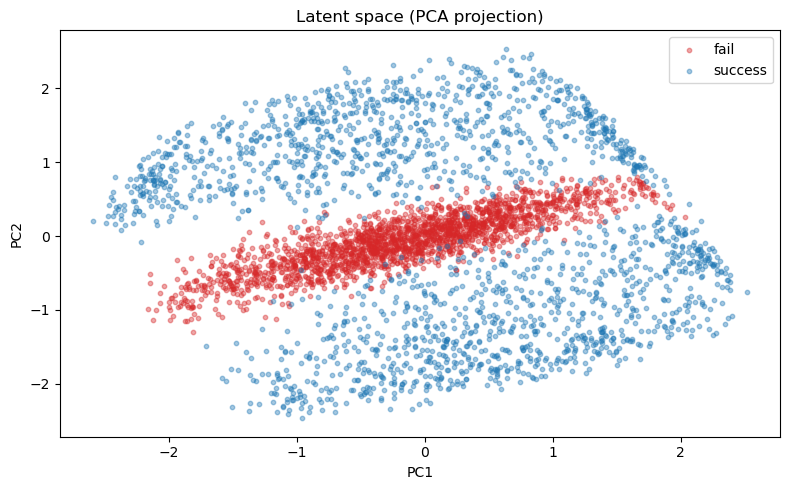

In [395]:
from sklearn.decomposition import PCA

Z = model.embed(X_tensor.to(device)).cpu().numpy()  # (N, LATENT_DIM)
Z_success = Z[success]
Z_fail = Z[~success]

# PCA to 2D for visualization
pca = PCA(n_components=2).fit(Z)
Z2 = pca.transform(Z)
Z2_success = Z2[success]
Z2_fail = Z2[~success]
print(f"PCA explained variance: {pca.explained_variance_ratio_}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(Z2_fail[:, 0], Z2_fail[:, 1], c="C3", alpha=0.4, s=10, label="fail")
ax.scatter(Z2_success[:, 0], Z2_success[:, 1], c="C0", alpha=0.4, s=10, label="success")
ax.legend()
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Latent space (PCA projection)")
plt.tight_layout()

## 4. Fit CD polynomial (Hermite basis) on success latents

In [398]:
cd_degree = 5  # lower degree for 8D (n_terms grows fast)
spec = BasisSpec(n_vars=LATENT_DIM, degree=cd_degree)
hermite = HermiteBasis(spec)

Z_s_torch = torch.tensor(Z_success, dtype=torch.float32)
Phi = hermite.transform(Z_s_torch)  # (n_success, n_terms)
n_s = Phi.shape[0]

# Moment matrix and Cholesky
M = (Phi.T @ Phi) / n_s
M += 1e-5 * torch.eye(M.shape[0])
L_cd = torch.linalg.cholesky(M)

print(f"Hermite basis: {hermite}")
print(f"Moment matrix cond: {torch.linalg.cond(M):.2e}")

Hermite basis: HermiteBasis(n_vars=2, degree=5, n_terms=21)
Moment matrix cond: 2.63e+03


CD threshold (n_terms): 21
Success P(z): mean=21.0, max=331.1
Fail    P(z): mean=37.6, max=589.0


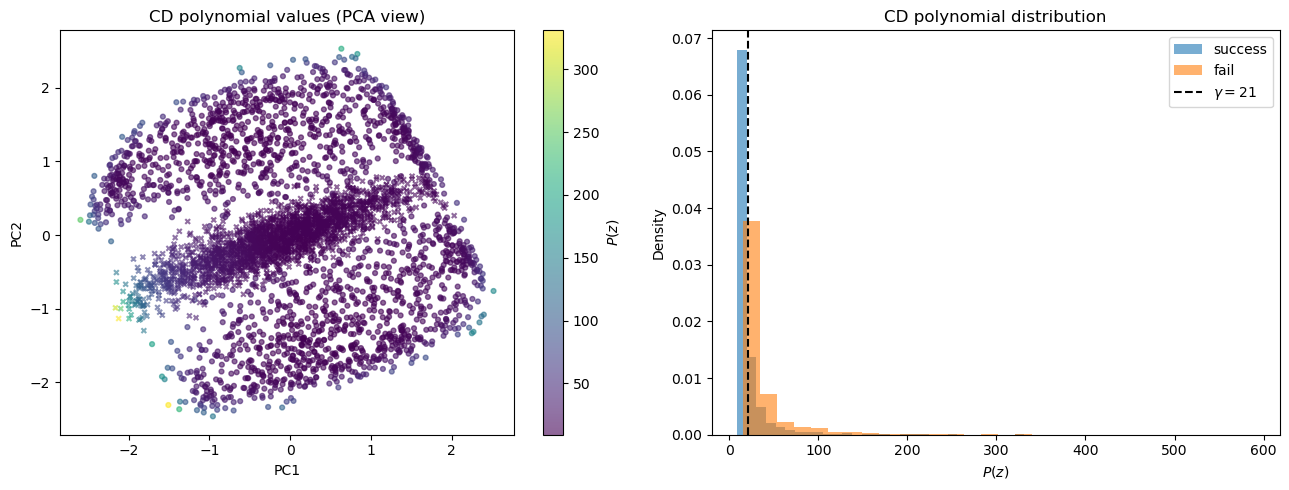

In [399]:
def eval_cd(z, hermite, L_cd):
    """Evaluate P(z) = ||L^{-T} phi(z)||^2."""
    phi = hermite.transform(torch.tensor(z, dtype=torch.float32))
    y = torch.linalg.solve_triangular(L_cd, phi.T, upper=False).T
    return (y * y).sum(dim=1).numpy()

# Evaluate CD on all data points
P_success = eval_cd(Z_success, hermite, L_cd)
P_fail = eval_cd(Z_fail, hermite, L_cd)
gamma = hermite.n_terms  # classical threshold

print(f"CD threshold (n_terms): {gamma}")
print(f"Success P(z): mean={P_success.mean():.1f}, max={P_success.max():.1f}")
print(f"Fail    P(z): mean={P_fail.mean():.1f}, max={P_fail.max():.1f}")

# Visualize CD values projected onto PCA space
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(Z2_success[:, 0], Z2_success[:, 1], c=P_success, cmap="viridis", s=12, alpha=0.6)
ax.scatter(Z2_fail[:, 0], Z2_fail[:, 1], c=P_fail, cmap="viridis", s=12, alpha=0.6, marker="x")
plt.colorbar(sc, ax=ax, label="$P(z)$")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("CD polynomial values (PCA view)")

ax = axes[1]
ax.hist(P_success, bins=30, alpha=0.6, label="success", density=True)
ax.hist(P_fail, bins=30, alpha=0.6, label="fail", density=True)
ax.axvline(gamma, color="k", ls="--", label=f"$\\gamma = {gamma}$")
ax.set_xlabel("$P(z)$"); ax.set_ylabel("Density")
ax.set_title("CD polynomial distribution")
ax.legend()

plt.tight_layout()

## 5. Polynomial regression of trajectory length in latent space

In [400]:
# Regress length ~ polynomial(z) using Hermite features + least squares
Z_torch = torch.tensor(Z, dtype=torch.float32)
L_true = torch.tensor(lengths, dtype=torch.float32)

results = {}
for deg in range(1, 7):  # keep degree modest for 8D
    h = HermiteBasis(BasisSpec(n_vars=LATENT_DIM, degree=deg))
    Phi_all = h.transform(Z_torch)  # (N, n_terms)
    # Least squares: Phi @ w = L_true
    w, _, _, _ = torch.linalg.lstsq(Phi_all, L_true)
    L_pred = Phi_all @ w
    residuals = L_true - L_pred
    ss_res = (residuals ** 2).sum().item()
    ss_tot = ((L_true - L_true.mean()) ** 2).sum().item()
    r2 = 1 - ss_res / ss_tot
    results[deg] = {"r2": r2, "n_terms": h.n_terms, "w": w, "pred": L_pred}
    print(f"deg={deg:2d}  n_terms={h.n_terms:4d}  R²={r2:.4f}")

deg= 1  n_terms=   3  R²=0.0288
deg= 2  n_terms=   6  R²=0.8780
deg= 3  n_terms=  10  R²=0.8820
deg= 4  n_terms=  15  R²=0.8940
deg= 5  n_terms=  21  R²=0.8973
deg= 6  n_terms=  28  R²=0.9197


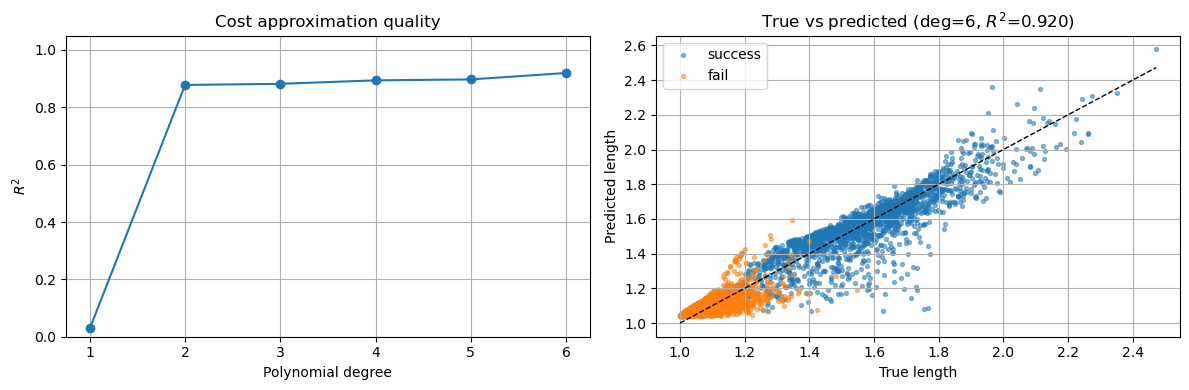

In [401]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² vs degree
degs = sorted(results.keys())
r2s = [results[d]["r2"] for d in degs]
axes[0].plot(degs, r2s, "o-")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("$R^2$")
axes[0].set_title("Cost approximation quality")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True)

# True vs predicted for best degree
best_deg = max(results, key=lambda d: results[d]["r2"])
L_pred = results[best_deg]["pred"].detach().numpy()
axes[1].scatter(lengths[success], L_pred[success], s=8, alpha=0.5, label="success")
axes[1].scatter(lengths[~success], L_pred[~success], s=8, alpha=0.5, label="fail")
lims = [lengths.min(), lengths.max()]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("True length")
axes[1].set_ylabel("Predicted length")
axes[1].set_title(f"True vs predicted (deg={best_deg}, $R^2$={results[best_deg]['r2']:.3f})")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

## 6. Cost function level sets in latent space

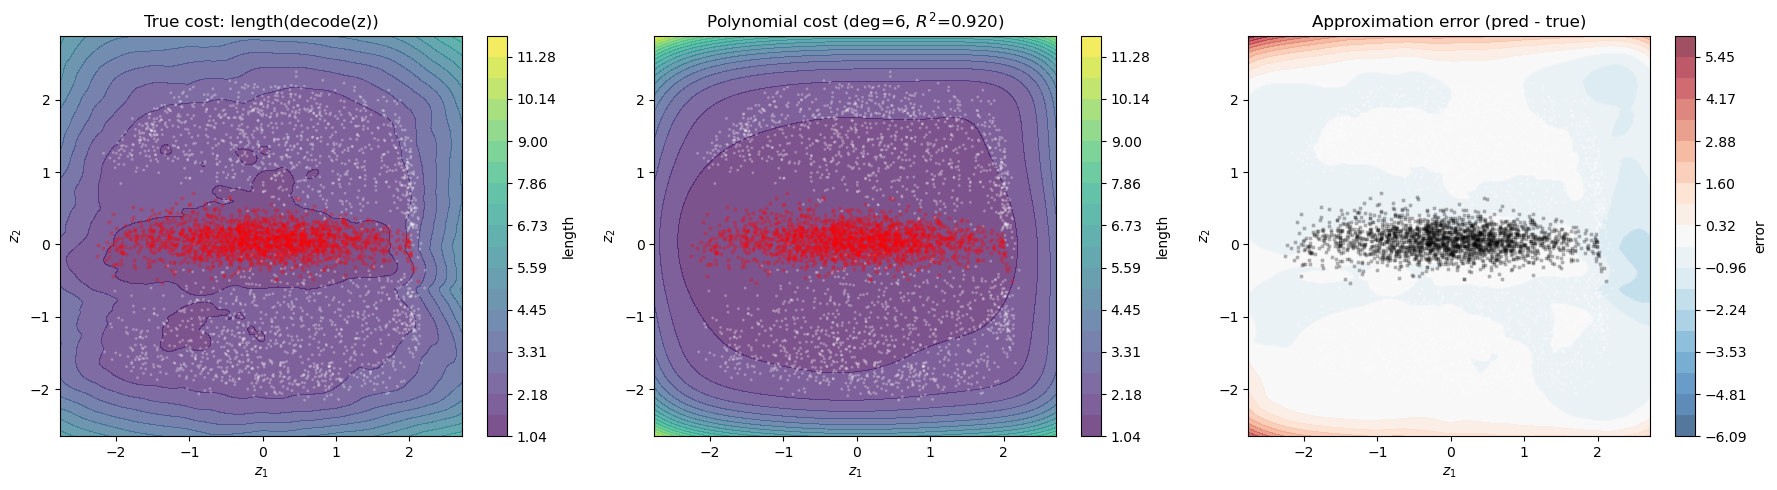

In [402]:
# Pick a good degree for the cost polynomial
cost_deg = best_deg
h_cost = HermiteBasis(BasisSpec(n_vars=LATENT_DIM, degree=cost_deg))
w_cost = results[cost_deg]["w"]

# Build 2D grid — directly in latent space if 2D, else PCA slice
if LATENT_DIM == 2:
    margin = 0.5
    g1_range = np.linspace(Z[:, 0].min() - margin, Z[:, 0].max() + margin, 200)
    g2_range = np.linspace(Z[:, 1].min() - margin, Z[:, 1].max() + margin, 200)
    G1, G2 = np.meshgrid(g1_range, g2_range)
    z_grid = np.column_stack([G1.ravel(), G2.ravel()])
    Z_plot = Z  # for scatter
    Z_plot_success = Z[success]
    Z_plot_fail = Z[~success]
    xlabel, ylabel = "$z_1$", "$z_2$"
else:
    margin = 0.5
    g1_range = np.linspace(Z2[:, 0].min() - margin, Z2[:, 0].max() + margin, 200)
    g2_range = np.linspace(Z2[:, 1].min() - margin, Z2[:, 1].max() + margin, 200)
    G1, G2 = np.meshgrid(g1_range, g2_range)
    z2_grid = np.column_stack([G1.ravel(), G2.ravel()])
    z_grid = pca.inverse_transform(z2_grid)
    Z_plot_success = Z2_success
    Z_plot_fail = Z2_fail
    xlabel, ylabel = "PC1", "PC2"

# Predicted cost on grid (polynomial)
Phi_grid = h_cost.transform(torch.tensor(z_grid, dtype=torch.float32))
cost_pred_grid = (Phi_grid @ w_cost).detach().numpy().reshape(G1.shape)

# True cost on grid: decode each grid point and compute trajectory length
z_grid_torch = torch.tensor(z_grid, dtype=torch.float32).to(device)
with torch.no_grad():
    trajs_grid = model.decode(z_grid_torch).cpu().numpy()
cost_true_grid = np.array([trajectory_length(t) for t in trajs_grid]).reshape(G1.shape)

# Error
cost_error_grid = cost_pred_grid - cost_true_grid

# Shared levels for true/pred
vmin = min(cost_true_grid.min(), cost_pred_grid.min())
vmax = max(cost_true_grid.max(), cost_pred_grid.max())
levels = np.linspace(vmin, vmax, 20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
cs = ax.contourf(G1, G2, cost_true_grid, levels=levels, cmap="viridis", alpha=0.7)
plt.colorbar(cs, ax=ax, label="length")
ax.scatter(Z_plot_success[:, 0], Z_plot_success[:, 1], c="white", s=4, alpha=0.3, edgecolors="none")
ax.scatter(Z_plot_fail[:, 0], Z_plot_fail[:, 1], c="red", s=4, alpha=0.3, marker="x")
ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
ax.set_title("True cost: length(decode(z))")

ax = axes[1]
cs = ax.contourf(G1, G2, cost_pred_grid, levels=levels, cmap="viridis", alpha=0.7)
plt.colorbar(cs, ax=ax, label="length")
ax.scatter(Z_plot_success[:, 0], Z_plot_success[:, 1], c="white", s=4, alpha=0.3, edgecolors="none")
ax.scatter(Z_plot_fail[:, 0], Z_plot_fail[:, 1], c="red", s=4, alpha=0.3, marker="x")
ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
ax.set_title(f"Polynomial cost (deg={cost_deg}, $R^2$={results[cost_deg]['r2']:.3f})")

ax = axes[2]
emax = max(abs(cost_error_grid.min()), abs(cost_error_grid.max()))
err_levels = np.linspace(-emax, emax, 20)
cs = ax.contourf(G1, G2, cost_error_grid, levels=err_levels, cmap="RdBu_r", alpha=0.7)
plt.colorbar(cs, ax=ax, label="error")
ax.scatter(Z_plot_success[:, 0], Z_plot_success[:, 1], c="white", s=4, alpha=0.3, edgecolors="none")
ax.scatter(Z_plot_fail[:, 0], Z_plot_fail[:, 1], c="k", s=4, alpha=0.3, marker="x")
ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
ax.set_title("Approximation error (pred - true)")

plt.tight_layout()